# 07 — Test Set Evaluation & Failure Analysis

 **Purpose:** Load best checkpoint, evaluate on the held-out test set,
 save per-image metrics, predicted masks, overlays, and failure cases.

 **This notebook does NOT:** train, retrain, or use the validation set.

# 1  Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import torch
import torch.nn as nn
import torchvision.transforms.functional as TF

In [3]:
import segmentation_models_pytorch as smp
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
print(f"torch {torch.__version__}  |  smp {smp.__version__}  |  CUDA {torch.cuda.is_available()}")


torch 2.6.0+cu124  |  smp 0.5.0  |  CUDA True


# 2  Constants

In [4]:
OUTPUT_ROOT   = Path(r"D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs")
TEST_MANIFEST = OUTPUT_ROOT / "03_splits" / "segmentation_test_manifest.csv"
BEST_CKPT     = OUTPUT_ROOT / "05_training_runs" / "checkpoints" / "best_efficientnetb0_unet.pth"

IMG_SIZE      = 384
BATCH_SIZE    = 8
NUM_WORKERS   = 0
PIN_MEMORY    = torch.cuda.is_available()
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
THRESHOLD     = 0.5
FAILURE_N     = 30    # worst-Dice cases to save

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

assert TEST_MANIFEST.exists(), f"Not found: {TEST_MANIFEST}"
assert BEST_CKPT.exists(),     f"Best checkpoint not found: {BEST_CKPT} — run Notebook 6 first."
print(f"Device: {DEVICE}  |  Checkpoint: {BEST_CKPT.name}")

Device: cuda  |  Checkpoint: best_efficientnetb0_unet.pth


# 3  Create Output Directories

In [5]:
PRED_DIR     = OUTPUT_ROOT / "06_predictions"
MASK_DIR     = PRED_DIR / "test_predicted_masks"
OVERLAY_DIR  = PRED_DIR / "test_overlays"
FAILURE_DIR  = PRED_DIR / "failure_cases"
REPORTS_DIR  = OUTPUT_ROOT / "07_reports"
AUDIT_DIR    = OUTPUT_ROOT / "04_visual_audits"

for d in [MASK_DIR, OVERLAY_DIR, FAILURE_DIR, REPORTS_DIR, AUDIT_DIR]:
    d.mkdir(parents=True, exist_ok=True)
    print(f"Ready: {d}")

Ready: D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs\06_predictions\test_predicted_masks
Ready: D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs\06_predictions\test_overlays
Ready: D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs\06_predictions\failure_cases
Ready: D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs\07_reports
Ready: D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs\04_visual_audits


# 4  Dataset (no augmentation)

In [6]:
class TongueSegmentationDataset(Dataset):
    def __init__(self, manifest_path: Path, img_size: int):
        self.df       = pd.read_csv(manifest_path)
        self.img_size = img_size
        for col in ["sample_id","patient_id","image_path","mask_path"]:
            assert col in self.df.columns, f"Missing: {col}"

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        img  = Image.open(row["image_path"]).convert("RGB")
        mask = Image.open(row["mask_path"]).convert("L")
        img  = TF.resize(img,  [self.img_size, self.img_size],
                          interpolation=TF.InterpolationMode.BILINEAR)
        mask = TF.resize(mask, [self.img_size, self.img_size],
                          interpolation=TF.InterpolationMode.NEAREST)
        img_t  = TF.normalize(TF.to_tensor(img), IMAGENET_MEAN, IMAGENET_STD)
        mask_t = (TF.to_tensor(mask) > 0.5).float()
        meta = {
            "sample_id" : str(row["sample_id"]),
            "patient_id": str(row["patient_id"]),
            "image_path": str(row["image_path"]),
            "mask_path" : str(row["mask_path"]),
        }
        return img_t, mask_t, meta

test_dataset = TongueSegmentationDataset(TEST_MANIFEST, IMG_SIZE)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
print(f"Test samples: {len(test_dataset)}  |  Batches: {len(test_loader)}")


Test samples: 804  |  Batches: 101


# 5  Load Model & Best Checkpoint

In [7]:
model = smp.Unet(
    encoder_name   ="efficientnet-b0",
    encoder_weights=None,      # weights come from checkpoint
    in_channels    =3,
    classes        =1,
    activation     =None,
).to(DEVICE)

ckpt = torch.load(BEST_CKPT, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

print(f"Checkpoint loaded — epoch {ckpt['epoch']}  val_dice={ckpt['val_dice']:.4f}")


Checkpoint loaded — epoch 40  val_dice=0.9935


# 6  Per-Image Evaluation Loop
Sigmoid + threshold 0.5 applied. Predicted masks saved as binary PNG {0, 255}.

In [8]:
bce_loss_fn = nn.BCEWithLogitsLoss(reduction="none")

def per_image_metrics(logits_1hw, target_1hw, threshold=0.5):
    prob  = torch.sigmoid(logits_1hw)
    pred  = (prob >= threshold).float()
    pf    = pred.view(-1)
    tf    = target_1hw.view(-1)
    tp    = (pf * tf).sum()
    fp    = (pf * (1-tf)).sum()
    fn    = ((1-pf) * tf).sum()
    tn    = ((1-pf) * (1-tf)).sum()
    eps   = 1e-7
    return {
        "dice"     : ((2*tp+eps)/(2*tp+fp+fn+eps)).item(),
        "iou"      : ((tp+eps)/(tp+fp+fn+eps)).item(),
        "precision": ((tp+eps)/(tp+fp+eps)).item(),
        "recall"   : ((tp+eps)/(tp+fn+eps)).item(),
        "pixel_acc": ((tp+tn)/(tp+tn+fp+fn+eps)).item(),
    }

_MEAN = torch.tensor(IMAGENET_MEAN).view(3,1,1)
_STD  = torch.tensor(IMAGENET_STD).view(3,1,1)

def denormalize(t):
    return ((t.cpu()*_STD+_MEAN).clamp(0,1).permute(1,2,0).numpy()*255).astype("uint8")

records = []

with torch.no_grad():
    for images, masks, metas in tqdm(test_loader, desc="Evaluating test set"):
        images = images.to(DEVICE, non_blocking=True)
        masks  = masks.to(DEVICE,  non_blocking=True)
        logits = model(images)
        probs  = torch.sigmoid(logits)
        preds  = (probs >= THRESHOLD).float()

        # BCE per image
        bce_per = bce_loss_fn(logits, masks).mean(dim=[1,2,3])

        for i in range(len(images)):
            m   = per_image_metrics(logits[i], masks[i])
            sid = metas["sample_id"][i]

            # Save predicted mask as binary PNG {0, 255}
            pred_np  = (preds[i].cpu().squeeze(0).numpy()*255).astype("uint8")
            mask_pil = Image.fromarray(pred_np, mode="L")
            mask_save_path = MASK_DIR / f"{sid}_pred_mask.png"
            mask_pil.save(str(mask_save_path))

            # Save overlay
            orig_arr = denormalize(images[i].cpu())
            ov       = orig_arr.copy().astype("float32")
            tp_px    = pred_np == 255
            ov[tp_px,0] = (ov[tp_px,0]*0.5+127).clip(0,255)
            ov[tp_px,1] = (ov[tp_px,1]*0.5).clip(0,255)
            ov[tp_px,2] = (ov[tp_px,2]*0.5).clip(0,255)
            Image.fromarray(ov.astype("uint8")).save(str(OVERLAY_DIR / f"{sid}_overlay.png"))

            records.append({
                "sample_id"      : sid,
                "patient_id"     : metas["patient_id"][i],
                "image_path"     : metas["image_path"][i],
                "mask_path"      : metas["mask_path"][i],
                "pred_mask_path" : str(mask_save_path),
                "dice"           : round(m["dice"],       6),
                "iou"            : round(m["iou"],        6),
                "precision"      : round(m["precision"],  6),
                "recall"         : round(m["recall"],     6),
                "pixel_acc"      : round(m["pixel_acc"],  6),
                "bce_loss"       : round(bce_per[i].item(), 6),
            })

print(f"Evaluation complete — {len(records)} test images processed.")

Evaluating test set: 100%|██████████| 101/101 [00:57<00:00,  1.75it/s]

Evaluation complete — 804 test images processed.


# 7  Save Per-Image Metrics CSV

In [9]:
metrics_df = pd.DataFrame(records)
METRICS_CSV = PRED_DIR / "test_per_image_metrics.csv"
metrics_df.to_csv(METRICS_CSV, index=False)
print(f"Per-image metrics saved -> {METRICS_CSV}")
metrics_df.describe()

Per-image metrics saved -> D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs\06_predictions\test_per_image_metrics.csv


,dice,iou,precision,recall,pixel_acc,bce_loss
count,804.000000,804.000000,804.000000,804.000000,804.000000,804.000000
mean,0.993752,0.987625,0.993572,0.993988,0.994655,0.015920
std,0.004711,0.009079,0.006354,0.007457,0.003649,0.019680
min,0.937506,0.882363,0.890116,0.901280,0.955770,0.003786
25%,0.993021,0.986139,0.992201,0.993087,0.993922,0.007786
50%,0.994866,0.989786,0.995162,0.996129,0.995565,0.010828
75%,0.996251,0.992529,0.996854,0.997493,0.996623,0.016580
max,0.998006,0.996020,0.999611,0.999768,0.998420,0.277696


# 8  Summary Statistics

In [10]:
dice_arr = metrics_df["dice"].values
iou_arr  = metrics_df["iou"].values

mean_dice = np.mean(dice_arr);   median_dice = np.median(dice_arr); std_dice = np.std(dice_arr)
mean_iou  = np.mean(iou_arr);    median_iou  = np.median(iou_arr);  std_iou  = np.std(iou_arr)
min_dice  = np.min(dice_arr)

n_below_90 = int((dice_arr < 0.90).sum())
n_below_80 = int((dice_arr < 0.80).sum())
n_below_70 = int((dice_arr < 0.70).sum())

print("=" * 56)
print("TEST SET EVALUATION SUMMARY")
print("=" * 56)
print(f"  N test images        : {len(metrics_df)}")
print(f"  Dice  mean/med/std   : {mean_dice:.4f} / {median_dice:.4f} / {std_dice:.4f}")
print(f"  IoU   mean/med/std   : {mean_iou:.4f}  / {median_iou:.4f}  / {std_iou:.4f}")
print(f"  Min Dice             : {min_dice:.4f}")
print(f"  Cases Dice < 0.90    : {n_below_90}")
print(f"  Cases Dice < 0.80    : {n_below_80}")
print(f"  Cases Dice < 0.70    : {n_below_70}")
print("=" * 56)


TEST SET EVALUATION SUMMARY
  N test images        : 804
  Dice  mean/med/std   : 0.9938 / 0.9949 / 0.0047
  IoU   mean/med/std   : 0.9876  / 0.9898  / 0.0091
  Min Dice             : 0.9375
  Cases Dice < 0.90    : 0
  Cases Dice < 0.80    : 0
  Cases Dice < 0.70    : 0


# 9  Save Test Evaluation Report

In [11]:
REPORT_PATH = REPORTS_DIR / "07_test_evaluation_report.txt"

lines = [
    "=" * 56,
    "TEST EVALUATION REPORT — EfficientNet-B0 U-Net",
    "=" * 56,
    f"  Checkpoint      : {BEST_CKPT.name}",
    f"  Val Dice (train): {ckpt['val_dice']:.6f}",
    f"  N test images   : {len(metrics_df)}",
    "-" * 56,
    "DICE",
    f"  Mean   : {mean_dice:.6f}",
    f"  Median : {median_dice:.6f}",
    f"  Std    : {std_dice:.6f}",
    f"  Min    : {min_dice:.6f}",
    "IoU",
    f"  Mean   : {mean_iou:.6f}",
    f"  Median : {median_iou:.6f}",
    f"  Std    : {std_iou:.6f}",
    "-" * 56,
    "FAILURE THRESHOLDS",
    f"  Dice < 0.90 : {n_below_90} ({100*n_below_90/len(metrics_df):.1f}%)",
    f"  Dice < 0.80 : {n_below_80} ({100*n_below_80/len(metrics_df):.1f}%)",
    f"  Dice < 0.70 : {n_below_70} ({100*n_below_70/len(metrics_df):.1f}%)",
    "=" * 56,
]
text = "\n".join(lines)
print(text)
with open(REPORT_PATH, "w", encoding="utf-8") as f:
    f.write(text + "\n")
print(f"\nReport saved -> {REPORT_PATH}")


TEST EVALUATION REPORT — EfficientNet-B0 U-Net
  Checkpoint      : best_efficientnetb0_unet.pth
  Val Dice (train): 0.993547
  N test images   : 804
--------------------------------------------------------
DICE
  Mean   : 0.993752
  Median : 0.994866
  Std    : 0.004708
  Min    : 0.937506
IoU
  Mean   : 0.987625
  Median : 0.989786
  Std    : 0.009073
--------------------------------------------------------
FAILURE THRESHOLDS
  Dice < 0.90 : 0 (0.0%)
  Dice < 0.80 : 0 (0.0%)
  Dice < 0.70 : 0 (0.0%)

Report saved -> D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs\07_reports\07_test_evaluation_report.txt


# 10  Identify & Save Failure Cases (worst 30 by Dice)

In [12]:
worst_df = metrics_df.nsmallest(FAILURE_N, "dice").reset_index(drop=True)
print(f"Worst {FAILURE_N} Dice scores: {worst_df['dice'].min():.4f} – {worst_df['dice'].max():.4f}")

for _, row in worst_df.iterrows():
    src = Path(row["pred_mask_path"])
    dst = FAILURE_DIR / src.name
    if src.exists() and not dst.exists():
        import shutil
        shutil.copy2(src, dst)

print(f"Failure case masks copied to -> {FAILURE_DIR}")

Worst 30 Dice scores: 0.9375 – 0.9850
Failure case masks copied to -> D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs\06_predictions\failure_cases


# 11  Visual Grids: Random / Best / Worst Dice Cases

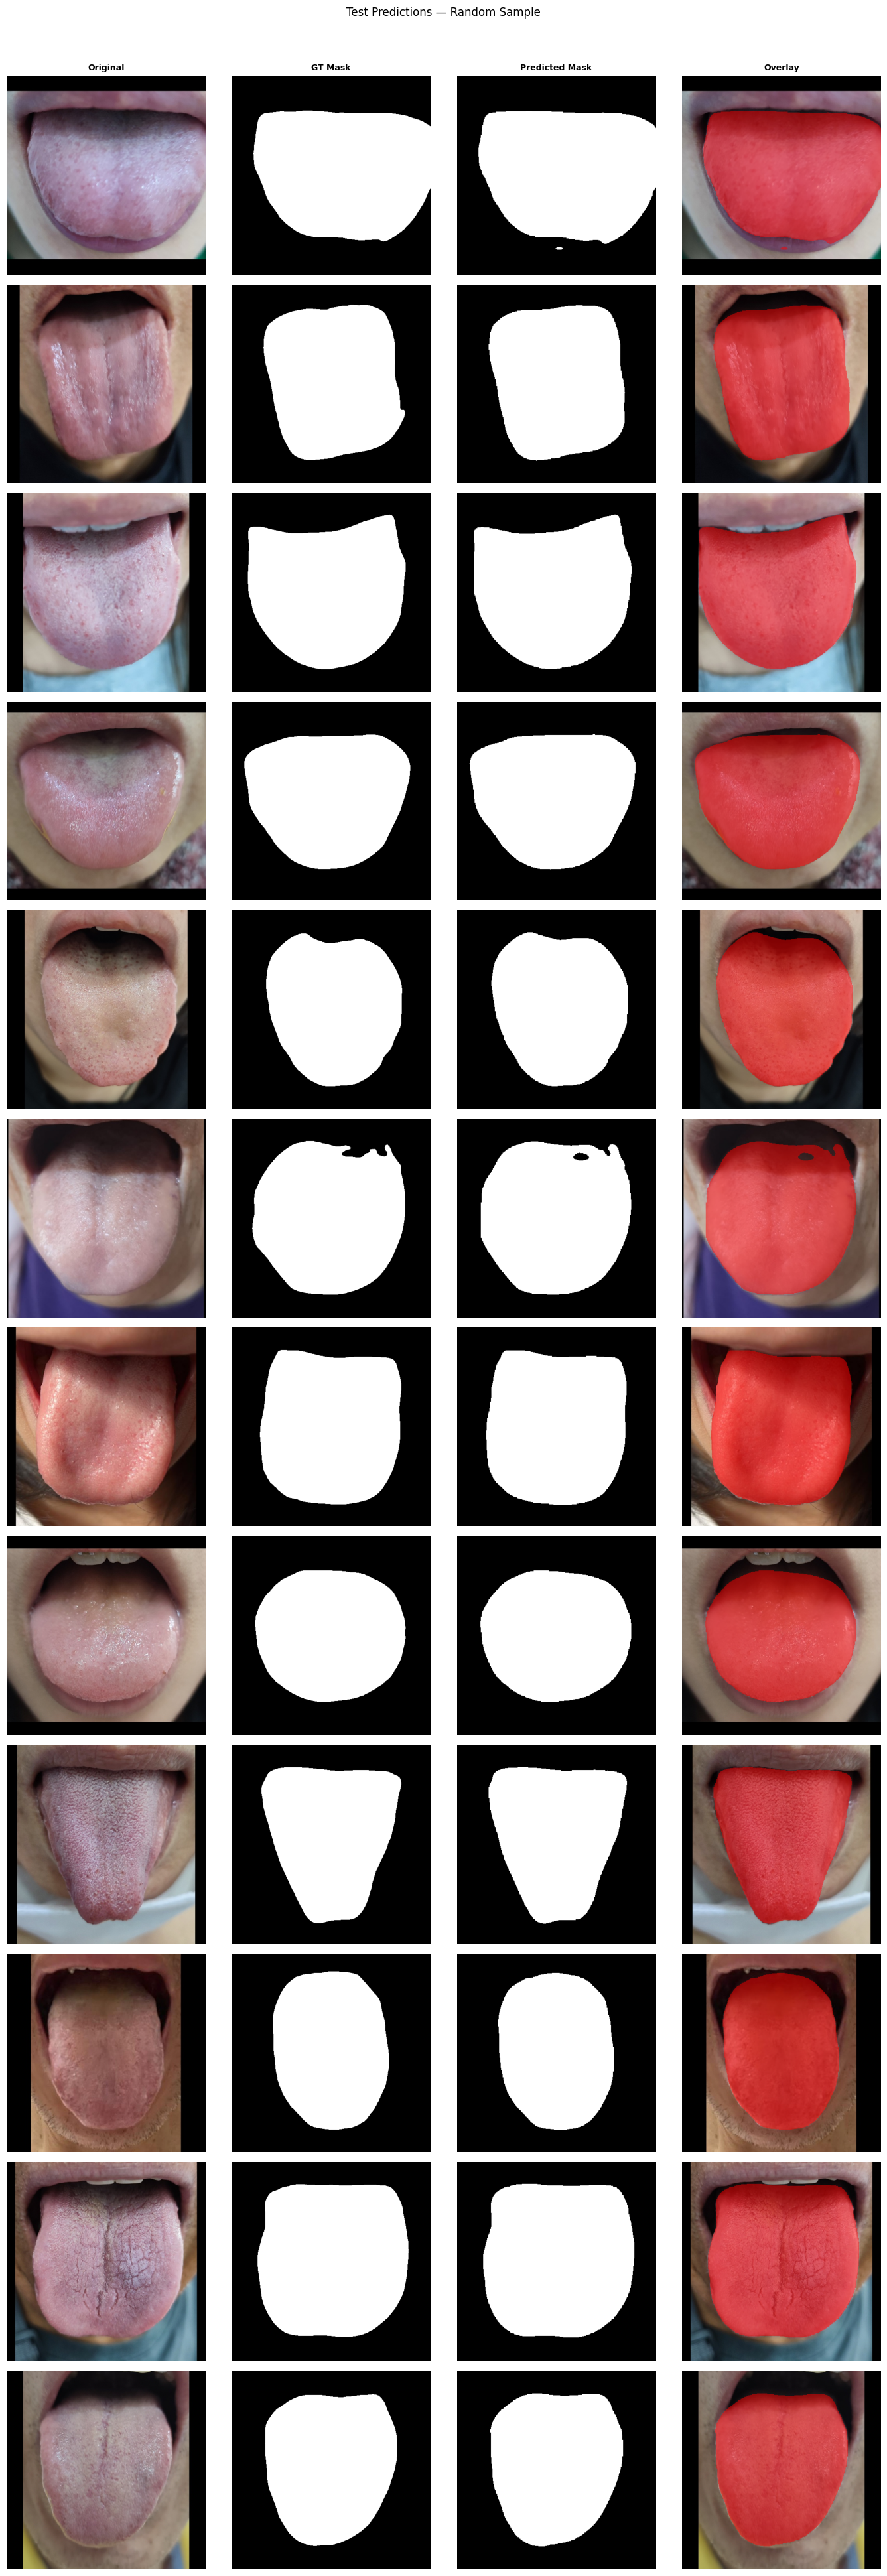

Saved -> D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs\04_visual_audits\07_test_random_predictions.png


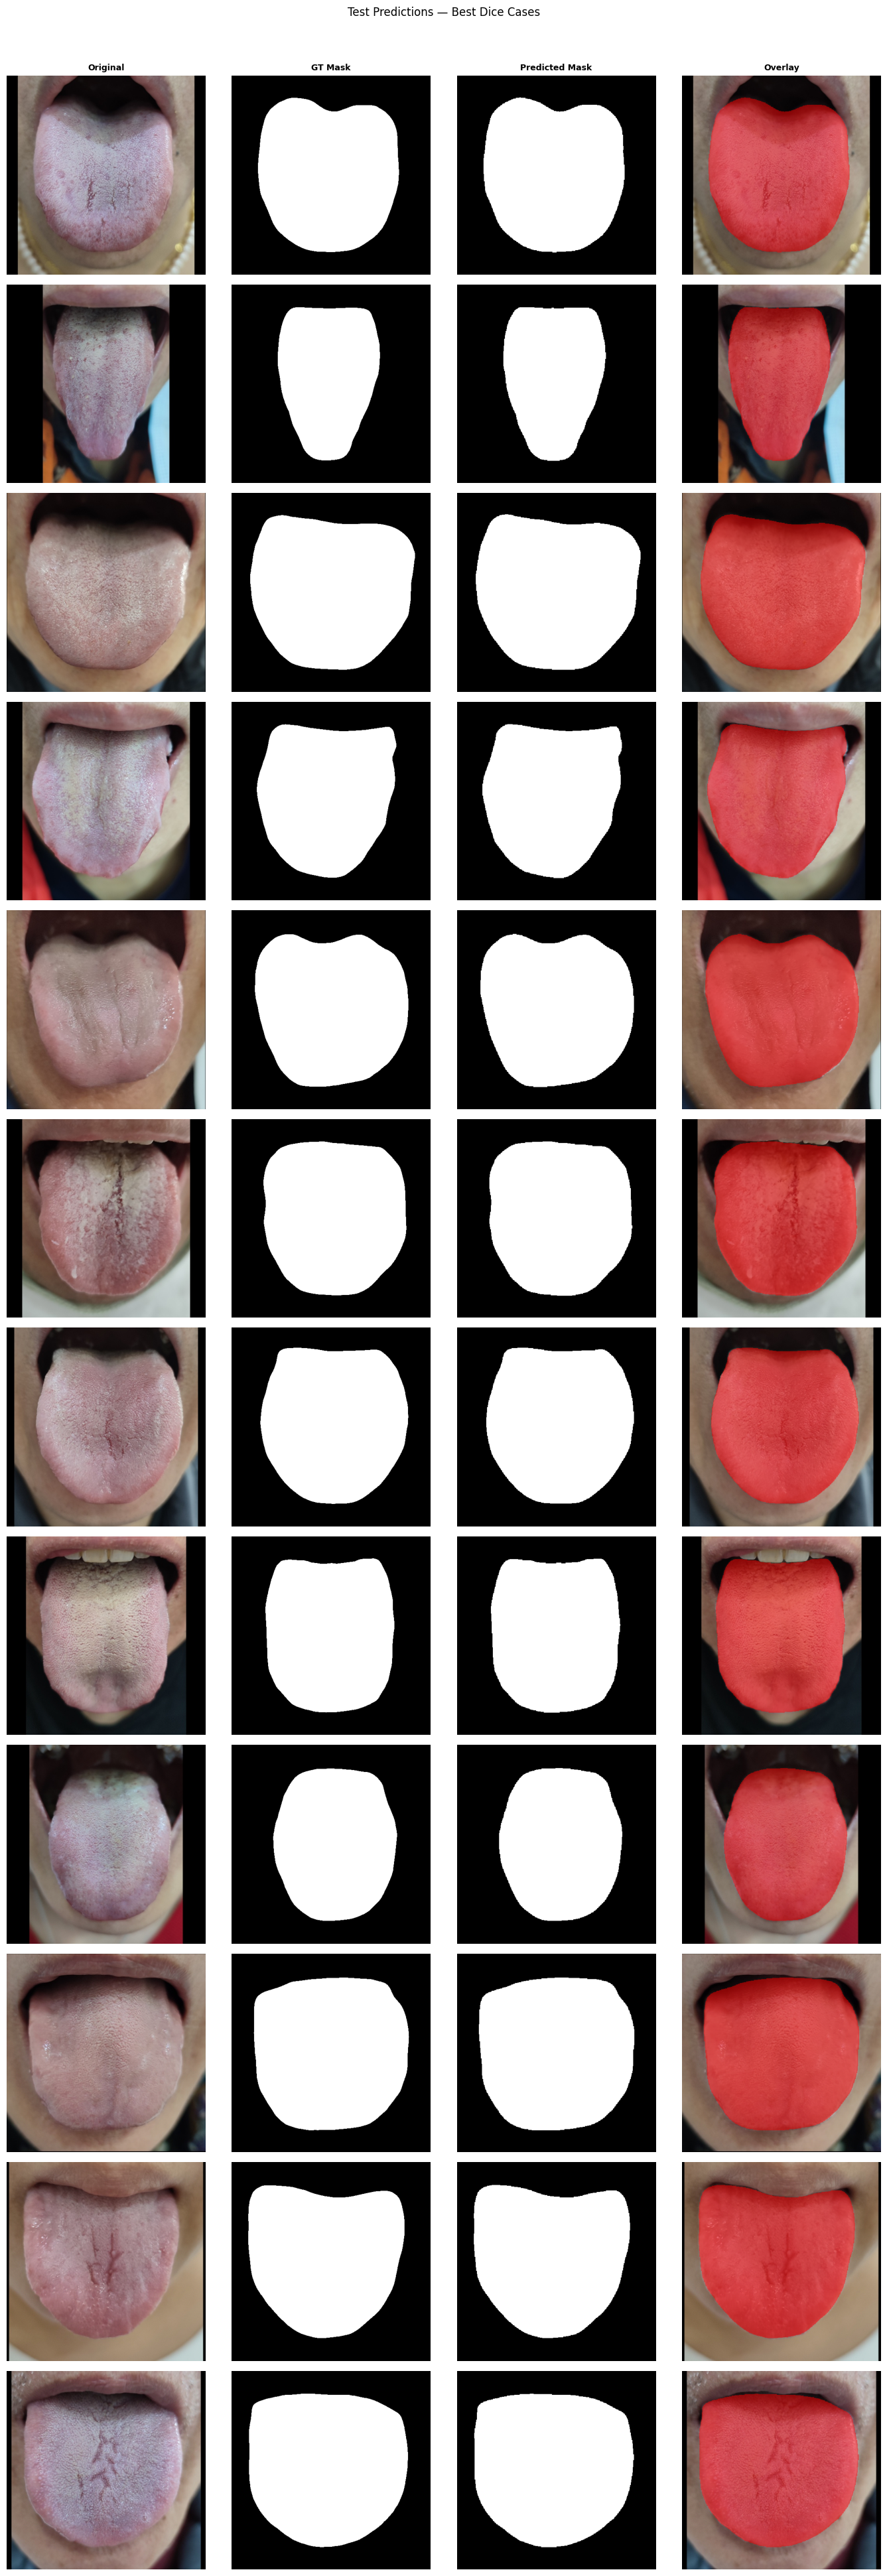

Saved -> D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs\04_visual_audits\07_test_best_dice_cases.png


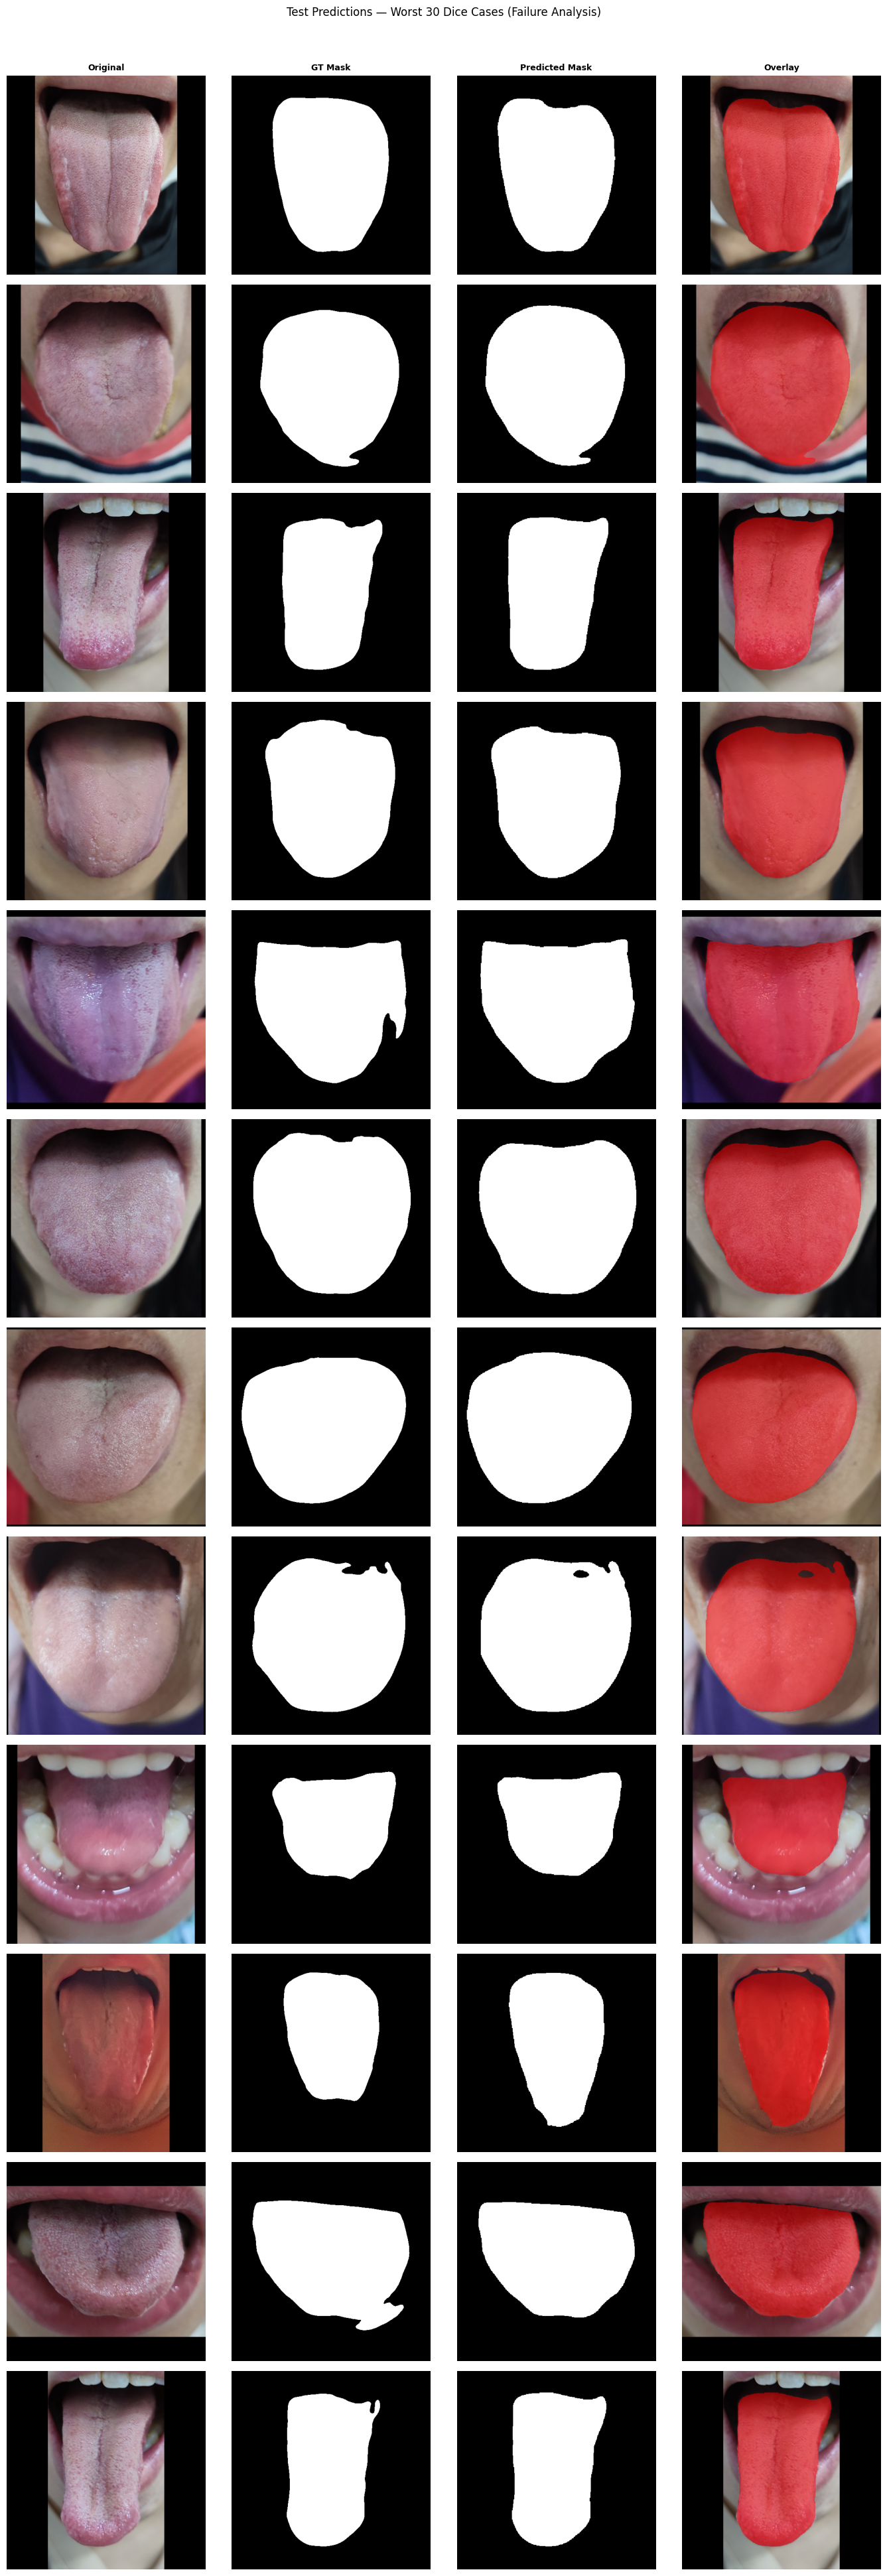

Saved -> D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs\04_visual_audits\07_test_worst_dice_cases.png


In [14]:
def build_visual_grid(subset_df, title, save_path, n=12):
    sample = subset_df.sample(n=min(n, len(subset_df)), random_state=42).reset_index(drop=True)
    n_show = len(sample)
    fig, axes = plt.subplots(n_show, 4, figsize=(14, n_show*3.2), squeeze=False)
    
    for c, h in enumerate(["Original","GT Mask","Predicted Mask","Overlay"]):
        axes[0,c].set_title(h, fontsize=9, fontweight="bold")

    for i, row in sample.iterrows():
        # 1. Load Original Image
        try:
            orig_img = Image.open(row["image_path"]).convert("RGB")
            orig = np.array(orig_img)
        except Exception:
            orig = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype="uint8")
            orig_img = Image.fromarray(orig)
            
        h_orig, w_orig = orig.shape[0], orig.shape[1]

        # 2. Load and Resize GT Mask to match original dimensions
        try:
            gt_img = Image.open(row["mask_path"]).convert("L")
            if gt_img.size != (w_orig, h_orig):
                gt_img = gt_img.resize((w_orig, h_orig), Image.Resampling.NEAREST)
            gt = np.array(gt_img)
        except Exception:
            gt = np.zeros((h_orig, w_orig), dtype="uint8")

        # 3. Load and Resize Predicted Mask to match original dimensions
        try:
            pred_img = Image.open(row["pred_mask_path"]).convert("L")
            if pred_img.size != (w_orig, h_orig):
                pred_img = pred_img.resize((w_orig, h_orig), Image.Resampling.NEAREST)
            pred = np.array(pred_img)
        except Exception:
            pred = np.zeros((h_orig, w_orig), dtype="uint8")

        # 4. Generate Overlay (Safe now because dimensions match!)
        ov = orig.copy().astype("float32")
        tp = pred == 255
        ov[tp, 0] = (ov[tp, 0] * 0.5 + 127).clip(0, 255)
        ov[tp, 1] = (ov[tp, 1] * 0.5).clip(0, 255)
        ov[tp, 2] = (ov[tp, 2] * 0.5).clip(0, 255)

        # 5. Plotting
        axes[i,0].imshow(orig)
        axes[i,1].imshow(gt,   cmap="gray", vmin=0, vmax=255)
        axes[i,2].imshow(pred, cmap="gray", vmin=0, vmax=255)
        axes[i,3].imshow(ov.astype("uint8"))
        
        for c in range(4): 
            axes[i,c].axis("off")
            
        axes[i,0].set_ylabel(
            f"{row['sample_id']}\ndice={row['dice']:.3f}",
            fontsize=6, rotation=0, labelpad=70, va="center")

    fig.suptitle(title, fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {save_path}")


# Random predictions
build_visual_grid(
    metrics_df,
    title="Test Predictions — Random Sample",
    save_path=AUDIT_DIR / "07_test_random_predictions.png",
)

# Best Dice cases
best_df = metrics_df.nlargest(12, "dice").reset_index(drop=True)
build_visual_grid(
    best_df,
    title="Test Predictions — Best Dice Cases",
    save_path=AUDIT_DIR / "07_test_best_dice_cases.png",
    n=12,
)

# Worst Dice cases
build_visual_grid(
    worst_df,
    title=f"Test Predictions — Worst {FAILURE_N} Dice Cases (Failure Analysis)",
    save_path=AUDIT_DIR / "07_test_worst_dice_cases.png",
    n=min(12, FAILURE_N),
)

# Notebook Complete

 | Output | Path |
 |--------|------|
 | Per-image metrics CSV | `06_predictions/test_per_image_metrics.csv` |
 | Predicted masks (PNG) | `06_predictions/test_predicted_masks/` |
 | Overlays | `06_predictions/test_overlays/` |
 | Failure cases | `06_predictions/failure_cases/` |
 | Test report | `07_reports/07_test_evaluation_report.txt` |
 | Visual grids | `04_visual_audits/07_test_*.png` |

 **No training was performed. Validation set was not used.**
 **Next step:** run `08_local_inference_export.ipynb`.